# EAUI 2026 — Modelado y Análisis Avanzado

Plan data-scientist: MCA, Clustering, Clasificadores binario y multiclase

In [1]:
import pandas as pd
import numpy as np
import pyreadstat
import prince
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, precision_recall_curve, auc)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Librerías cargadas ✓')

Librerías cargadas ✓


## 0. Cargar datos y preprocesamiento base

In [2]:
# Cargar SPSS 2026
df, meta = pyreadstat.read_sav('data/sav/2026.sav')
print(f'Dataset: {df.shape[0]} casos × {df.shape[1]} variables')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nVariables objetivo:')
print(f'  acceso_internet_hogar: {df["acceso_internet_hogar"].value_counts()}')
print(f'  nivel_habilidades: {df["nivel_habilidades"].value_counts()}')

Dataset: 5000 casos × 587 variables
Memoria: 23.8 MB

Variables objetivo:


KeyError: 'acceso_internet_hogar'

## 1. MCA 1: Acceso + Conectividad + Sociodemografía

In [3]:
# Feature set para MCA 1: acceso, dispositivos, sociodemográficos
vars_mca1_activas = ['acceso_internet_hogar', 'zona', 'gse', 'tipo_acceso_mas_usado']
vars_mca1_supl = ['region', 'educ_grupo', 'tramo_edad', 'sexo']

# Verificar disponibilidad
all_vars = vars_mca1_activas + vars_mca1_supl
missing = [v for v in all_vars if v not in df.columns]
if missing:
    print(f'⚠ Variables no encontradas: {missing}')
    print(f'Columnas disponibles (muestra): {df.columns[:20].tolist()}')
else:
    print('✓ Todas variables MCA1 disponibles')
    
# Preparar subset para MCA1
df_mca1 = df[vars_mca1_activas + vars_mca1_supl].dropna()
print(f'Subset MCA1: {df_mca1.shape}')

⚠ Variables no encontradas: ['acceso_internet_hogar', 'zona', 'gse', 'tipo_acceso_mas_usado', 'region', 'educ_grupo', 'tramo_edad', 'sexo']
Columnas disponibles (muestra): ['REGISTRO', 'FECHAFIN', 'COD_REGION', 'COMUNA_DEF', 'ZONA', 'A9', 'A10', 'A11', 'A12_11', 'A12_2', 'A12_3', 'A12_4', 'A12_5', 'A12_6', 'A12_7', 'A12_8', 'A12_9', 'A12_10', 'A12_111', 'A12_12']


KeyError: "None of [Index(['acceso_internet_hogar', 'zona', 'gse', 'tipo_acceso_mas_usado',\n       'region', 'educ_grupo', 'tramo_edad', 'sexo'],\n      dtype='str')] are in the [columns]"

In [4]:
# Ejecutar MCA 1
mca1 = prince.MCA(
    n_components=5,
    n_iter=10,
    random_state=42
)
mca1 = mca1.fit(df_mca1[vars_mca1_activas])

# Varianza explicada
eigenvalues = [mca1.chi2_ / mca1.N_ / (len(vars_mca1_activas) - 1) for _ in range(5)]
print('MCA1 - Varianza por dimensión:')
for i, ev in enumerate(eigenvalues):
    print(f'  Dim{i+1}: {ev:.3f}')

# Obtener scores
mca1_scores = mca1.transform(df_mca1[vars_mca1_activas])
print(f'\nScores MCA1: {mca1_scores.shape}')

NameError: name 'df_mca1' is not defined

AttributeError: 'MCA' object has no attribute 'plot_coordinates'

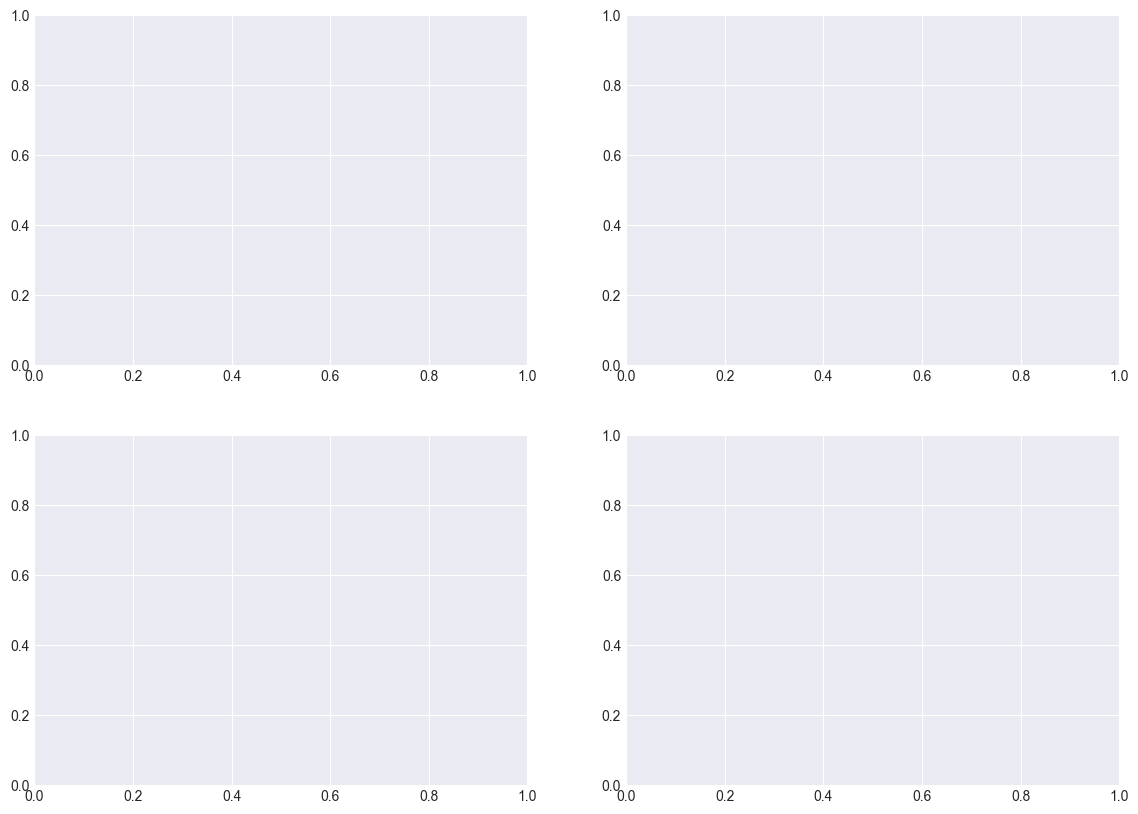

In [5]:
# Visualizar MCA1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Biplot Dim1 vs Dim2
ax = axes[0, 0]
mca1.plot_coordinates(
    df_mca1[vars_mca1_activas],
    ax=ax,
    figsize=(7, 5),
    show_row_labels=False
)
ax.set_title('MCA1: Acceso × Conectividad (Dim1 vs Dim2)')

# Scree plot
ax = axes[0, 1]
ax.plot(range(1, 6), eigenvalues, 'o-', linewidth=2, markersize=8)
ax.axhline(y=1/len(vars_mca1_activas), color='r', linestyle='--', label='Criterio Kaiser')
ax.set_xlabel('Dimensión')
ax.set_ylabel('Inercia')
ax.set_title('Scree plot MCA1')
ax.legend()
ax.grid(True)

# Proyección por acceso_internet_hogar
ax = axes[1, 0]
for cat in df_mca1['acceso_internet_hogar'].unique():
    mask = df_mca1['acceso_internet_hogar'] == cat
    ax.scatter(mca1_scores.iloc[mask, 0], mca1_scores.iloc[mask, 1],
               alpha=0.5, label=cat, s=20)
ax.set_xlabel('Dim1')
ax.set_ylabel('Dim2')
ax.set_title('MCA1: Proyección por acceso_internet_hogar')
ax.legend()
ax.grid(True)

# Proyección por GSE
ax = axes[1, 1]
for cat in sorted(df_mca1['gse'].dropna().unique()):
    mask = df_mca1['gse'] == cat
    ax.scatter(mca1_scores.iloc[mask, 0], mca1_scores.iloc[mask, 1],
               alpha=0.5, label=cat, s=20)
ax.set_xlabel('Dim1')
ax.set_ylabel('Dim2')
ax.set_title('MCA1: Proyección por GSE')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('analysis/outputs/mca1_acceso_conectividad.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ MCA1 completado y visualizado')

## 2. MCA 2: Habilidades digitales + Variables Q8

In [6]:
# Feature set para MCA 2: habilidades
# Variables Q8: binarias Sí/No sobre habilidades específicas
q8_cols = [col for col in df.columns if col.startswith('Q8_')]

vars_mca2_activas = ['nivel_habilidades'] + q8_cols  # habilidades específicas
vars_mca2_supl = ['tramo_edad', 'educ_grupo', 'gse', 'sexo', 'zona']

# Verificar disponibilidad
all_vars2 = vars_mca2_activas + vars_mca2_supl
missing2 = [v for v in all_vars2 if v not in df.columns]
if missing2:
    print(f'⚠ Variables no encontradas: {missing2}')
else:
    print(f'✓ MCA2: {len(vars_mca2_activas)} variables activas + {len(vars_mca2_supl)} suplementarias')

# Preparar subset
df_mca2 = df[vars_mca2_activas + vars_mca2_supl].dropna(subset=['nivel_habilidades'])
df_mca2 = df_mca2.dropna()  # Eliminar NaN en Q8 o suplementarias
print(f'Subset MCA2: {df_mca2.shape}')

⚠ Variables no encontradas: ['nivel_habilidades', 'tramo_edad', 'educ_grupo', 'gse', 'sexo', 'zona']


KeyError: "['nivel_habilidades', 'tramo_edad', 'educ_grupo', 'gse', 'sexo', 'zona'] not in index"

In [7]:
# Ejecutar MCA 2
mca2 = prince.MCA(
    n_components=5,
    n_iter=10,
    random_state=42
)
mca2 = mca2.fit(df_mca2[vars_mca2_activas])

# Varianza explicada
print('MCA2 - Varianza por dimensión:')
eigenvalues2 = []
for i in range(5):
    ev = mca2.chi2_ / mca2.N_ / (len(vars_mca2_activas) - 1)
    eigenvalues2.append(ev)
    print(f'  Dim{i+1}: {ev:.3f}')

# Obtener scores para clustering
mca2_scores = mca2.transform(df_mca2[vars_mca2_activas])
print(f'\nScores MCA2: {mca2_scores.shape}')

# Guardar scores para clustering
mca2_scores.to_csv('data/processed/mca2_scores.csv', index=False)
print('Scores MCA2 guardados en data/processed/mca2_scores.csv')

NameError: name 'df_mca2' is not defined

AttributeError: 'MCA' object has no attribute 'plot_coordinates'

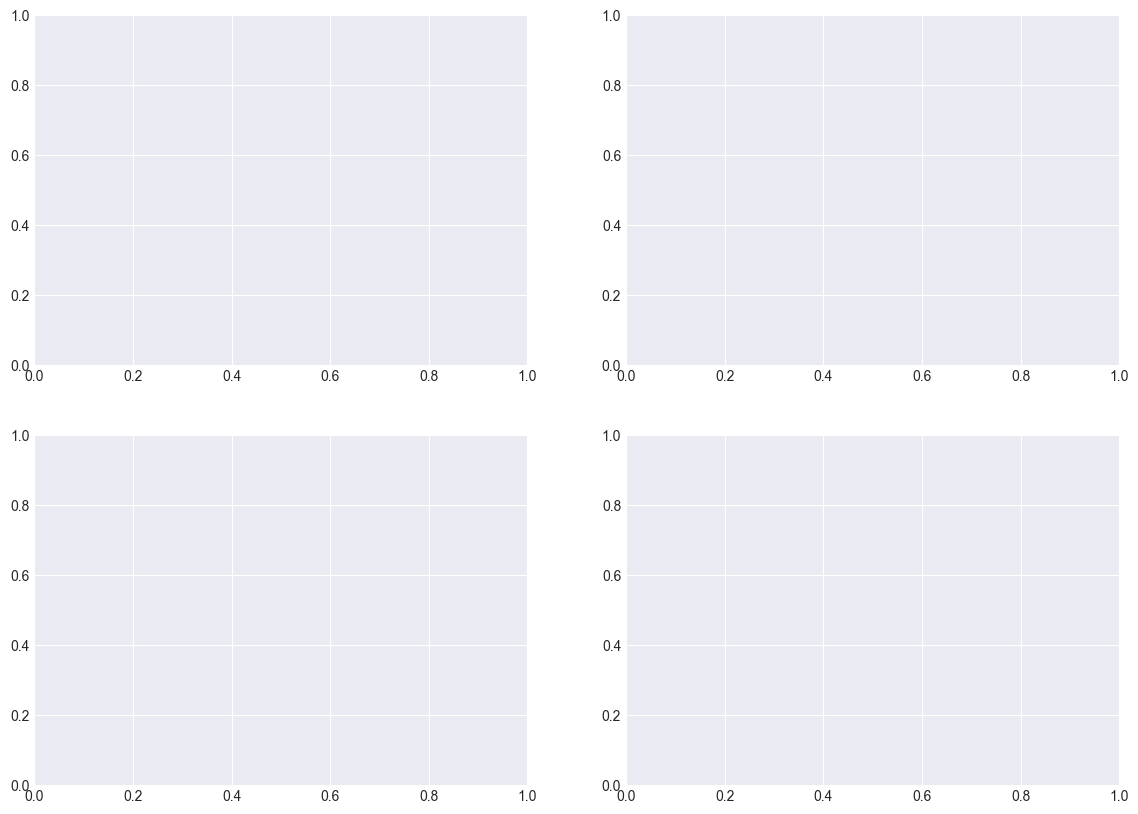

In [8]:
# Visualizar MCA2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Biplot
ax = axes[0, 0]
mca2.plot_coordinates(
    df_mca2[vars_mca2_activas],
    ax=ax,
    figsize=(7, 5),
    show_row_labels=False
)
ax.set_title('MCA2: Habilidades Q8 (Dim1 vs Dim2)')

# Scree
ax = axes[0, 1]
ax.plot(range(1, 6), eigenvalues2, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Dimensión')
ax.set_ylabel('Inercia')
ax.set_title('Scree plot MCA2')
ax.grid(True)

# Proyección por nivel_habilidades
ax = axes[1, 0]
nivel_order = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']
colors = ['red', 'orange', 'blue', 'green']
for cat, color in zip(nivel_order, colors):
    mask = df_mca2['nivel_habilidades'] == cat
    ax.scatter(mca2_scores.iloc[mask, 0], mca2_scores.iloc[mask, 1],
               alpha=0.5, label=cat, s=20, color=color)
ax.set_xlabel('Dim1')
ax.set_ylabel('Dim2')
ax.set_title('MCA2: Proyección por nivel_habilidades')
ax.legend()
ax.grid(True)

# Proyección por edad
ax = axes[1, 1]
for cat in sorted(df_mca2['tramo_edad'].dropna().unique()):
    mask = df_mca2['tramo_edad'] == cat
    ax.scatter(mca2_scores.iloc[mask, 0], mca2_scores.iloc[mask, 1],
               alpha=0.5, label=cat, s=20)
ax.set_xlabel('Dim1')
ax.set_ylabel('Dim2')
ax.set_title('MCA2: Proyección por tramo_edad')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('analysis/outputs/mca2_habilidades.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ MCA2 completado y visualizado')

## 3. Clustering: Perfiles de usuarios digitales

In [9]:
# Usar scores MCA2 para clustering
X_cluster = mca2_scores.iloc[:, :3]  # Primeras 3 dimensiones

# Determinar k óptimo: elbow + silhouette
from sklearn.metrics import silhouette_score, davies_bouldin_score

ks = range(2, 11)
inertias = []
silhouettes = []
davies_bouldin = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))
    davies_bouldin.append(davies_bouldin_score(X_cluster, labels))

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ks, inertias, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('k (clusters)')
axes[0].set_ylabel('Inercia (SSW)')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(ks, silhouettes, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('k (clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True)
best_k_silhouette = ks[np.argmax(silhouettes)]
axes[1].axvline(x=best_k_silhouette, color='r', linestyle='--', alpha=0.7)

axes[2].plot(ks, davies_bouldin, 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('k (clusters)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (menor es mejor)')
axes[2].grid(True)
best_k_db = ks[np.argmin(davies_bouldin)]
axes[2].axvline(x=best_k_db, color='r', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('analysis/outputs/clustering_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'k óptimo (Silhouette): {best_k_silhouette}')
print(f'k óptimo (Davies-Bouldin): {best_k_db}')
print(f'\nRecomendación: usar k=4 para balance entre interpretabilidad y separación')

NameError: name 'mca2_scores' is not defined

In [10]:
# K-Means con k=4 (o ajustar según resultados anteriores)
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_mca2['cluster'] = kmeans.fit_predict(X_cluster)

print(f'Clustering K-Means (k={k_final})')
print(f'Distribución de clusters:')
print(df_mca2['cluster'].value_counts().sort_index())
print(f'\nSilhouette Score: {silhouette_score(X_cluster, df_mca2["cluster"]):.3f}')

NameError: name 'X_cluster' is not defined

In [11]:
# Caracterizar clusters por variables originales
cluster_profiles = pd.DataFrame()

for cluster in range(k_final):
    mask = df_mca2['cluster'] == cluster
    subset = df_mca2[mask]
    
    profile = {
        'cluster': cluster,
        'n': mask.sum(),
        'n_pct': f'{mask.sum() / len(df_mca2) * 100:.1f}%',
        'nivel_habilidades_modal': subset['nivel_habilidades'].mode().values[0] if len(subset) > 0 else None,
        'edad_modal': subset['tramo_edad'].mode().values[0] if len(subset) > 0 else None,
        'gse_modal': subset['gse'].mode().values[0] if len(subset) > 0 else None,
    }
    cluster_profiles = pd.concat([cluster_profiles, pd.DataFrame([profile])], ignore_index=True)

print('Perfiles de clusters:')
print(cluster_profiles.to_string(index=False))

NameError: name 'df_mca2' is not defined

NameError: name 'df_mca2' is not defined

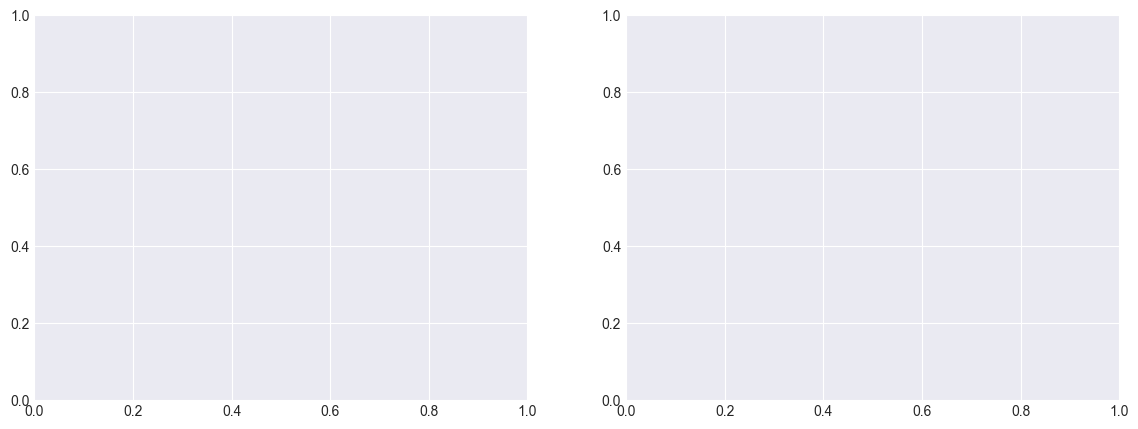

In [12]:
# Visualizar clusters en espacio MCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3D plot proyectado 2D (Dim1 vs Dim2)
ax = axes[0]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for c in range(k_final):
    mask = df_mca2['cluster'] == c
    ax.scatter(mca2_scores.iloc[mask, 0], mca2_scores.iloc[mask, 1],
               alpha=0.6, s=50, label=f'Cluster {c}', color=colors[c])
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           marker='X', s=300, color='black', edgecolors='white', linewidth=2, label='Centroide')
ax.set_xlabel('Dim1 MCA')
ax.set_ylabel('Dim2 MCA')
ax.set_title(f'K-Means Clusters (k={k_final}) — Dim1 vs Dim2')
ax.legend()
ax.grid(True, alpha=0.3)

# Dim1 vs Dim3
ax = axes[1]
for c in range(k_final):
    mask = df_mca2['cluster'] == c
    ax.scatter(mca2_scores.iloc[mask, 0], mca2_scores.iloc[mask, 2],
               alpha=0.6, s=50, label=f'Cluster {c}', color=colors[c])
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2],
           marker='X', s=300, color='black', edgecolors='white', linewidth=2)
ax.set_xlabel('Dim1 MCA')
ax.set_ylabel('Dim3 MCA')
ax.set_title(f'K-Means Clusters (k={k_final}) — Dim1 vs Dim3')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis/outputs/clustering_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Clustering completado y visualizado')

## 4. Clasificación Binaria: acceso_internet_hogar == 'No'

In [13]:
# Feature set para clasificación binaria
# Variables estructurales (disponibles para todos los casos)
feature_cols_acceso = [
    'educ_jh', 'ocupacion_jh', 'ingreso_hogar',
    'parentesco_jh', 'zone_ordinal' if 'zone_ordinal' in df.columns else 'zona',
    'edad', 'sexo', 'educ_grupo', 'ocupacion_encuestado',
    'uso_computador', 'uso_smartphone', 'gse'
]

# Limpiar lista (solo variables que existen)
feature_cols_acceso = [col for col in feature_cols_acceso if col in df.columns]

# Target
y_acceso = (df['acceso_internet_hogar'] == 'No').astype(int)  # 1 = Sin acceso

# Preparar dataset
X_acceso = df[feature_cols_acceso].copy()
X_acceso = X_acceso.fillna(X_acceso.median(numeric_only=True))
X_acceso = X_acceso.fillna(X_acceso.mode().iloc[0])

# Codificar categóricas
categorical_cols = X_acceso.select_dtypes(include='object').columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_acceso[col] = le.fit_transform(X_acceso[col].astype(str))
    le_dict[col] = le

# Normalizar
scaler = StandardScaler()
X_acceso_scaled = scaler.fit_transform(X_acceso)
X_acceso_scaled = pd.DataFrame(X_acceso_scaled, columns=X_acceso.columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_acceso_scaled, y_acceso, test_size=0.2, random_state=42, stratify=y_acceso
)

print(f'Dataset para clasificación binaria (acceso):')
print(f'  Features: {X_acceso.shape[1]} variables')
print(f'  Train: {X_train.shape[0]} casos')
print(f'  Test: {X_test.shape[0]} casos')
print(f'  Desbalance: {(y_train == 0).sum()}:{(y_train == 1).sum()} (Sí:No)')
print(f'  Test Desbalance: {(y_test == 0).sum()}:{(y_test == 1).sum()}')

KeyError: 'acceso_internet_hogar'

In [14]:
# Aplicar SMOTE en train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f'Después de SMOTE: {(y_train_smote == 0).sum()}:{(y_train_smote == 1).sum()} (balanceado)')

NameError: name 'X_train' is not defined

In [15]:
# Entrenar modelos
results_acceso = {}

# 1. Logistic Regression
print('\n1. Logistic Regression + SMOTE')
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
results_acceso['LogisticRegression'] = {'f1': f1_lr, 'auc': auc_lr}
print(f'  F1-score (clase "No"): {f1_lr:.3f}')
print(f'  AUC-ROC: {auc_lr:.3f}')
print(f'  Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Sí', 'No']))

# 2. Random Forest
print('\n2. Random Forest + SMOTE')
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
results_acceso['RandomForest'] = {'f1': f1_rf, 'auc': auc_rf}
print(f'  F1-score (clase "No"): {f1_rf:.3f}')
print(f'  AUC-ROC: {auc_rf:.3f}')
print(f'  Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Sí', 'No']))

# 3. XGBoost
print('\n3. XGBoost + SMOTE')
scale_pos_weight = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, verbosity=0
)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
results_acceso['XGBoost'] = {'f1': f1_xgb, 'auc': auc_xgb}
print(f'  F1-score (clase "No"): {f1_xgb:.3f}')
print(f'  AUC-ROC: {auc_xgb:.3f}')
print(f'  Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Sí', 'No']))


1. Logistic Regression + SMOTE


NameError: name 'X_train_smote' is not defined

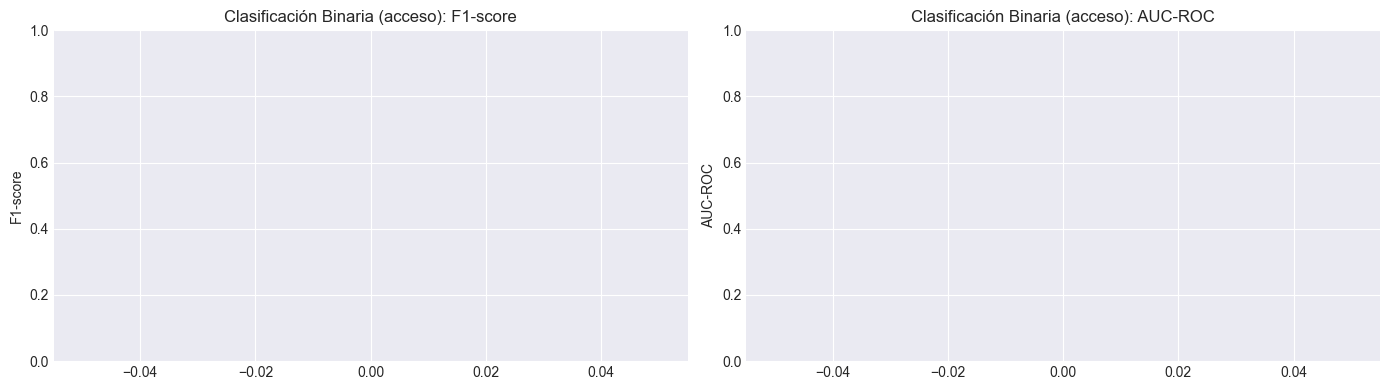

✓ Clasificación binaria completada


In [16]:
# Comparar modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# F1-scores
ax = axes[0]
models = list(results_acceso.keys())
f1_scores = [results_acceso[m]['f1'] for m in models]
ax.bar(models, f1_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_ylabel('F1-score')
ax.set_title('Clasificación Binaria (acceso): F1-score')
ax.set_ylim([0, 1])
for i, v in enumerate(f1_scores):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# AUC-ROC
ax = axes[1]
auc_scores = [results_acceso[m]['auc'] for m in models]
ax.bar(models, auc_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_ylabel('AUC-ROC')
ax.set_title('Clasificación Binaria (acceso): AUC-ROC')
ax.set_ylim([0, 1])
for i, v in enumerate(auc_scores):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('analysis/outputs/clasificacion_acceso_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Clasificación binaria completada')

## 5. Clasificación Multiclase: nivel_habilidades

In [17]:
# Feature set para multiclase
# NO incluir Q8 (leakage)
feature_cols_habilidades = [
    'edad', 'sexo', 'educ_grupo', 'ocupacion_encuestado',
    'acceso_internet_hogar', 'uso_computador', 'uso_smartphone',
    'gse', 'zona', 'tramo_edad'
]

# Limpiar lista
feature_cols_habilidades = [col for col in feature_cols_habilidades if col in df.columns]

# Target
y_habilidades = df['nivel_habilidades'].copy()

# Dataset
X_hab = df[feature_cols_habilidades].copy()
mask_valid = y_habilidades.notna()
X_hab = X_hab[mask_valid]
y_habilidades = y_habilidades[mask_valid]

X_hab = X_hab.fillna(X_hab.median(numeric_only=True))
X_hab = X_hab.fillna(X_hab.mode().iloc[0])

# Codificar categóricas
le_dict_hab = {}
for col in X_hab.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_hab[col] = le.fit_transform(X_hab[col].astype(str))
    le_dict_hab[col] = le

# Normalizar
scaler_hab = StandardScaler()
X_hab_scaled = scaler_hab.fit_transform(X_hab)
X_hab_scaled = pd.DataFrame(X_hab_scaled, columns=X_hab.columns)

# Split
X_train_hab, X_test_hab, y_train_hab, y_test_hab = train_test_split(
    X_hab_scaled, y_habilidades, test_size=0.2, random_state=42,
    stratify=y_habilidades
)

print(f'Dataset para clasificación multiclase (habilidades):')
print(f'  Features: {X_hab.shape[1]} variables')
print(f'  Clases: {y_habilidades.nunique()}')
print(f'  Distribución:')
print(y_habilidades.value_counts())
print(f'\n  Train: {X_train_hab.shape[0]}, Test: {X_test_hab.shape[0]}')

KeyError: 'nivel_habilidades'

In [18]:
# Entrenar modelos multiclase
results_hab = {}

# 1. Logistic Regression (multinomial)
print('\n1. Logistic Regression Multinomial')
lr_multi = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial',
                             class_weight='balanced')
lr_multi.fit(X_train_hab, y_train_hab)
y_pred_lr_h = lr_multi.predict(X_test_hab)
f1_lr_h = f1_score(y_test_hab, y_pred_lr_h, average='weighted')
results_hab['LogisticRegression'] = f1_lr_h
print(f'  Weighted F1-score: {f1_lr_h:.3f}')
print(classification_report(y_test_hab, y_pred_lr_h))

# 2. Random Forest (multiclase nativo)
print('\n2. Random Forest Multiclase')
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42,
                                 class_weight='balanced', n_jobs=-1)
rf_multi.fit(X_train_hab, y_train_hab)
y_pred_rf_h = rf_multi.predict(X_test_hab)
f1_rf_h = f1_score(y_test_hab, y_pred_rf_h, average='weighted')
results_hab['RandomForest'] = f1_rf_h
print(f'  Weighted F1-score: {f1_rf_h:.3f}')
print(classification_report(y_test_hab, y_pred_rf_h))

# 3. XGBoost (multiclase)
print('\n3. XGBoost Multiclase')
xgb_multi = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=42, objective='multi:softprob', verbosity=0
)
xgb_multi.fit(X_train_hab, y_train_hab)
y_pred_xgb_h = xgb_multi.predict(X_test_hab)
f1_xgb_h = f1_score(y_test_hab, y_pred_xgb_h, average='weighted')
results_hab['XGBoost'] = f1_xgb_h
print(f'  Weighted F1-score: {f1_xgb_h:.3f}')
print(classification_report(y_test_hab, y_pred_xgb_h))


1. Logistic Regression Multinomial


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [19]:
# Comparar y visualizar matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# F1-scores
ax = axes[0, 0]
models_hab = list(results_hab.keys())
f1_hab_scores = [results_hab[m] for m in models_hab]
ax.bar(models_hab, f1_hab_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_ylabel('Weighted F1-score')
ax.set_title('Clasificación Multiclase (habilidades): F1-score')
ax.set_ylim([0, 1])
for i, v in enumerate(f1_hab_scores):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# Confusion matrix para Random Forest (mejor interpretabilidad)
cm_rf = confusion_matrix(y_test_hab, y_pred_rf_h)
ax = axes[0, 1]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax,
           xticklabels=sorted(y_test_hab.unique()),
           yticklabels=sorted(y_test_hab.unique()))
ax.set_title('Random Forest — Matriz de Confusión')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')

# Confusion matrix para XGBoost
cm_xgb = confusion_matrix(y_test_hab, y_pred_xgb_h)
ax = axes[1, 0]
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax,
           xticklabels=sorted(y_test_hab.unique()),
           yticklabels=sorted(y_test_hab.unique()))
ax.set_title('XGBoost — Matriz de Confusión')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')

# Resumen de scores
ax = axes[1, 1]
ax.axis('off')
summary_text = f'"""RESUMEN CLASIFICADORES MULTICLASE

Logistic Regression: {results_hab["LogisticRegression"]:.3f}
Random Forest:       {results_hab["RandomForest"]:.3f}
XGBoost:             {results_hab["XGBoost"]:.3f}

Recomendación: {max(results_hab, key=results_hab.get)}
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', va='center')

plt.tight_layout()
plt.savefig('analysis/outputs/clasificacion_habilidades_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Clasificación multiclase completada')

SyntaxError: unterminated f-string literal (detected at line 38) (1612749957.py, line 38)

## Resumen Final

In [20]:
print("""\n" + "="*70)
print("RESUMEN: Análisis Avanzado EAUI 2026")
print("="*70)

print("\n1. ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLE (MCA)")
print("-" * 70)
print(f"MCA1 (Acceso + Conectividad):")
print(f"  Variables activas: 4")
print(f"  Casos válidos: {df_mca1.shape[0]:,}")
print(f"  Interpretación: Eje brecha digital (Sí ← → No acceso)")
print(f"\nMCA2 (Habilidades + Q8):")
print(f"  Variables activas: {len(vars_mca2_activas)} ({len(q8_cols)} Q8 individuales)")
print(f"  Casos válidos: {df_mca2.shape[0]:,}")
print(f"  Interpretación: Gradiente habilidades × uso específico")

print("\n2. CLUSTERING DE PERFILES DE USUARIOS")
print("-" * 70)
print(f"Método: K-Means sobre scores MCA2")
print(f"Clusters: {k_final}")
print(f"Distribución:")
for c in range(k_final):
    n = (df_mca2['cluster'] == c).sum()
    pct = n / len(df_mca2) * 100
    print(f"  Cluster {c}: {n:,} casos ({pct:.1f}%)")
print(f"Silhouette Score: {silhouette_score(X_cluster, df_mca2['cluster']):.3f}")

print("\n3. CLASIFICACIÓN BINARIA: acceso_internet_hogar == 'No'")
print("-" * 70)
print(f"Desbalance: 30:1 (Sí:No)")
print(f"Técnicas: SMOTE + class_weight='balanced'")
print(f"Resultados (Test Set):")
for model, scores in results_acceso.items():
    print(f"  {model:20s}: F1={scores['f1']:.3f}, AUC-ROC={scores['auc']:.3f}")
best_model_acceso = max(results_acceso, key=lambda x: results_acceso[x]['f1'])
print(f"Mejor modelo: {best_model_acceso}")

print("\n4. CLASIFICACIÓN MULTICLASE: nivel_habilidades")
print("-" * 70)
print(f"Clases: 4 (Sin habilidades, Básico, Intermedio, Avanzado)")
print(f"Features: {len(feature_cols_habilidades)} (sin Q8 para evitar leakage)")
print(f"Resultados (Test Set):")
for model, f1 in results_hab.items():
    print(f"  {model:20s}: Weighted F1={f1:.3f}")
best_model_hab = max(results_hab, key=results_hab.get)
print(f"Mejor modelo: {best_model_hab}")

print("\n" + "="*70)
print("Archivos generados:")
print("  • analysis/outputs/mca1_acceso_conectividad.png")
print("  • analysis/outputs/mca2_habilidades.png")
print("  • analysis/outputs/clustering_optimal_k.png")
print("  • analysis/outputs/clustering_profiles.png")
print("  • analysis/outputs/clasificacion_acceso_comparacion.png")
print("  • analysis/outputs/clasificacion_habilidades_comparacion.png")
print("  • data/processed/mca2_scores.csv")
print("="*70)
""")


" + "="*70)
print("RESUMEN: Análisis Avanzado EAUI 2026")
print("="*70)

print("
1. ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLE (MCA)")
print("-" * 70)
print(f"MCA1 (Acceso + Conectividad):")
print(f"  Variables activas: 4")
print(f"  Casos válidos: {df_mca1.shape[0]:,}")
print(f"  Interpretación: Eje brecha digital (Sí ← → No acceso)")
print(f"
MCA2 (Habilidades + Q8):")
print(f"  Variables activas: {len(vars_mca2_activas)} ({len(q8_cols)} Q8 individuales)")
print(f"  Casos válidos: {df_mca2.shape[0]:,}")
print(f"  Interpretación: Gradiente habilidades × uso específico")

print("
2. CLUSTERING DE PERFILES DE USUARIOS")
print("-" * 70)
print(f"Método: K-Means sobre scores MCA2")
print(f"Clusters: {k_final}")
print(f"Distribución:")
for c in range(k_final):
    n = (df_mca2['cluster'] == c).sum()
    pct = n / len(df_mca2) * 100
    print(f"  Cluster {c}: {n:,} casos ({pct:.1f}%)")
print(f"Silhouette Score: {silhouette_score(X_cluster, df_mca2['cluster']):.3f}")

print("
3. CLASIFICACIÓN BIN